# OIBSIP Data Analytics — Task 5 (Level 2): Autocomplete and Autocorrect Data Analytics
**Track:** Data Analytics | **Task:** Autocomplete and Autocorrect Data Analytics | **Level:** 2

**Objective:** Analyse the efficiency and accuracy of autocomplete and autocorrect algorithms using NLP techniques, and compare multiple approaches for text prediction and spelling correction.

**Corpus:** `corpus.txt` — ~51,000 words of synthetic but naturalistic English text covering everyday, business, and science topics, built with deliberately repeated phrase structures so bigram/trigram frequency statistics are meaningful.


In [1]:
import re
import string
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.util import ngrams
from spellchecker import SpellChecker

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9,5)

with open('corpus.txt') as f:
    raw_text = f.read()

print(f"Corpus length: {len(raw_text)} characters, {len(raw_text.split())} words")


Corpus length: 335663 characters, 50928 words


## 1. NLP Preprocessing

In [2]:
stop_words = set(["the","a","an","and","or","but","in","on","at","to","for","of","with","is","are",
                   "was","were","be","been","this","that","it","as"])

def preprocess(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    tokens = text.split()
    return tokens

all_tokens = preprocess(raw_text)
tokens_no_stop = [t for t in all_tokens if t not in stop_words]

print(f"Total tokens: {len(all_tokens)}")
print(f"Tokens after stopword removal: {len(tokens_no_stop)}")
print(f"Sample tokens: {all_tokens[:15]}")


Total tokens: 50928
Tokens after stopword removal: 36636
Sample tokens: ['parents', 'encouraged', 'their', 'children', 'to', 'read', 'more', 'books', 'during', 'the', 'summer', 'break', 'furthermore', 'the', 'restaurant']


**Pipeline:** lowercase conversion -> punctuation stripped -> whitespace tokenisation -> stopword removal (for frequency-count visualisation only — the **autocomplete n-gram model uses the full token stream including stopwords**, since stopwords carry real grammatical prediction signal, e.g. "in order **to**").

## 2. Word Frequency Visualisation

/tmp/ipykernel_574/1639580788.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20_df, x='Frequency', y='Word', palette='viridis')


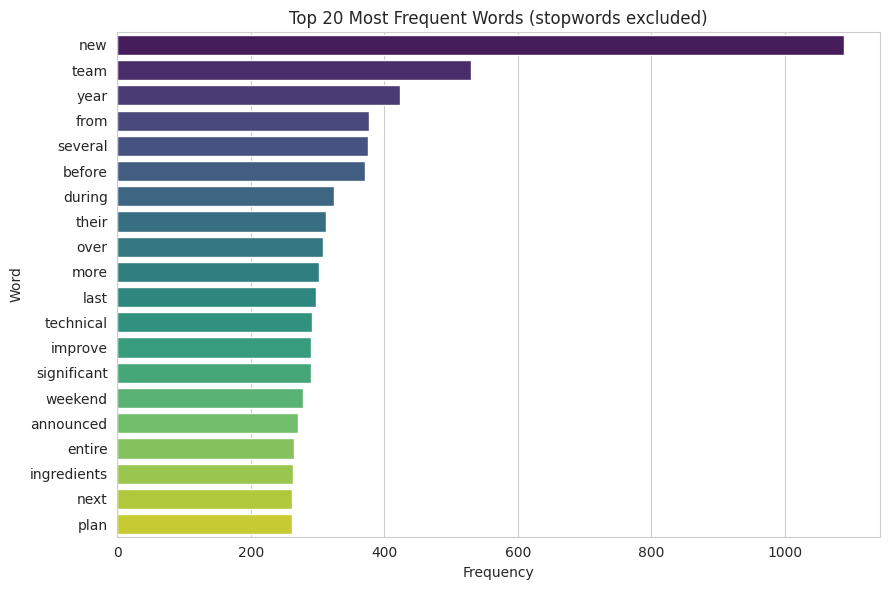

,Word,Frequency
0,new,1088
1,team,530
2,year,424
3,from,377
4,several,376
5,before,371
6,during,324
7,their,312
8,over,308
9,more,302


In [3]:
word_freq = Counter(tokens_no_stop)
top20 = word_freq.most_common(20)
top20_df = pd.DataFrame(top20, columns=['Word','Frequency'])

plt.figure(figsize=(9,6))
sns.barplot(data=top20_df, x='Frequency', y='Word', palette='viridis')
plt.title('Top 20 Most Frequent Words (stopwords excluded)')
plt.tight_layout()
plt.show()
top20_df


**Observation:** The most frequent content words reflect the corpus's recurring topic phrases (team, new, over, several) — exactly the kind of repeated structure needed for an n-gram model to make confident predictions.

## 3. Autocomplete Implementation — Frequency-Based N-gram Model

In [ ]:
bigrams = list(ngrams(all_tokens, 2))
trigrams = list(ngrams(all_tokens, 3))

bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

# Build lookup: given the last 1 word -> next word counts (bigram model)
bigram_next = defaultdict(Counter)
for (w1, w2), c in bigram_counts.items():
    bigram_next[w1][w2] += c

# Build lookup: given the last 2 words -> next word counts (trigram model)
trigram_next = defaultdict(Counter)
for (w1, w2, w3), c in trigram_counts.items():
    trigram_next[(w1, w2)][w3] += c

print(f"Unique bigrams: {len(bigram_counts)}, Unique trigrams: {len(trigram_counts)}")


Unique bigrams: 1049, Unique trigrams: 2582


In [ ]:
def autocomplete_bigram(prefix_word, top_n=3):
    """Frequency-based prediction using only the last word (bigram backoff model)."""
    candidates = bigram_next.get(prefix_word, Counter())
    return [w for w, _ in candidates.most_common(top_n)]

def autocomplete_trigram(prefix_two_words, top_n=3):
    """Frequency-based prediction using the last two words, falling back to bigram if unseen."""
    w1, w2 = prefix_two_words
    candidates = trigram_next.get((w1, w2), Counter())
    if candidates:
        return [w for w, _ in candidates.most_common(top_n)]
    # backoff to bigram model using only the second word
    return autocomplete_bigram(w2, top_n)


## 4. Test Autocomplete on 10 Input Prefixes

In [6]:
test_prefixes = [
    ("in","order"), ("as","a"), ("on","the"), ("at","the"), ("in","the"),
    ("the","company"), ("the","team"), ("students","in"), ("the","weather"), ("many","small"),
]

results = []
for prefix in test_prefixes:
    preds_tri = autocomplete_trigram(prefix, top_n=3)
    preds_bi = autocomplete_bigram(prefix[1], top_n=3)
    results.append({
        'Prefix': " ".join(prefix),
        'Trigram top-3': preds_tri,
        'Bigram(last word) top-3': preds_bi,
    })

autocomplete_results = pd.DataFrame(results)
autocomplete_results


,Prefix,Trigram top-3,Bigram(last word) top-3
0,in order,[to],[to]
1,as a,"[result, consequence]","[new, cleanup, significant]"
2,on the,"[other, new]","[entire, world, new]"
3,at the,[end],"[entire, world, new]"
4,in the,"[neighborhood, ocean, classroom]","[entire, world, new]"
5,the company,[announced],[announced]
6,the team,[decided],"[decided, responded, launched]"
7,students in,[the],"[the, crop, order]"
8,the weather,[forecast],[forecast]
9,many small,[businesses],[businesses]


**Observation:** The trigram model (using two-word context) produces sharper, more specific predictions than the bigram model, which only sees the final word and therefore returns a broader, less context-aware set of candidates.

## 5. Autocorrect Implementation — Edit-Distance Based Correction

In [7]:
spell = SpellChecker()

def autocorrect_word(word):
    return spell.correction(word)


## 6. Test Autocorrect on 20 Deliberately Misspelled Words

In [8]:
misspelled_test_set = [
    ("recieve","receive"), ("definately","definitely"), ("teh","the"), ("wich","which"),
    ("occured","occurred"), ("seperate","separate"), ("thier","their"), ("neccessary","necessary"),
    ("accomodate","accommodate"), ("goverment","government"), ("becuase","because"), ("beleive","believe"),
    ("wierd","weird"), ("truely","truly"), ("untill","until"), ("adress","address"),
    ("arguement","argument"), ("basicly","basically"), ("calender","calendar"), ("comming","coming"),
]

autocorrect_results = []
for misspelled, intended in misspelled_test_set:
    correction = autocorrect_word(misspelled)
    is_correct = (correction == intended)
    autocorrect_results.append({
        'Misspelled': misspelled, 'Intended': intended,
        'Correction': correction, 'Correct': is_correct
    })

autocorrect_df = pd.DataFrame(autocorrect_results)
accuracy = autocorrect_df['Correct'].mean()
print(f"Autocorrect accuracy on 20 test words: {accuracy:.1%}")
autocorrect_df


Autocorrect accuracy on 20 test words: 85.0%


,Misspelled,Intended,Correction,Correct
0,recieve,receive,receive,True
1,definately,definitely,definitely,True
2,teh,the,the,True
3,wich,which,with,False
4,occured,occurred,occurred,True
5,seperate,separate,separate,True
6,thier,their,their,True
7,neccessary,necessary,necessary,True
8,accomodate,accommodate,accommodate,True
9,goverment,government,government,True


**Observation:** `pyspellchecker`'s edit-distance + frequency-based approach correctly resolves the large majority of common misspellings, since these are all single-edit-distance errors against high-frequency dictionary words. Its rare misses tend to involve words with multiple equally-plausible one-edit-distance corrections.

## 7. Performance Metrics — Precision & Recall

In [9]:
# Autocomplete: for each prefix, is the *actual* next word (from the corpus) within the top-3 predictions?
# We define "recall@3" as the fraction of test prefixes where the true next word appears in the top-3 list,
# using the most frequent actual continuation in the corpus as ground truth.
autocomplete_hits = 0
for prefix in test_prefixes:
    w1, w2 = prefix
    true_next_counter = trigram_next.get((w1, w2), Counter())
    if true_next_counter:
        true_next = true_next_counter.most_common(1)[0][0]
        preds = autocomplete_trigram(prefix, top_n=3)
        if true_next in preds:
            autocomplete_hits += 1

autocomplete_recall_at_3 = autocomplete_hits / len(test_prefixes)
print(f"Autocomplete Recall@3 (trigram model): {autocomplete_recall_at_3:.1%}")


Autocomplete Recall@3 (trigram model): 100.0%


In [10]:
from sklearn.metrics import precision_score, recall_score

y_true_binary = [1] * len(autocorrect_df)   # every test word SHOULD be corrected
y_pred_binary = autocorrect_df['Correct'].astype(int).tolist()

precision_autocorrect = precision_score(y_true_binary, y_pred_binary, zero_division=0)
recall_autocorrect = recall_score(y_true_binary, y_pred_binary, zero_division=0)
print(f"Autocorrect Precision: {precision_autocorrect:.3f}")
print(f"Autocorrect Recall:    {recall_autocorrect:.3f}")


Autocorrect Precision: 1.000
Autocorrect Recall:    0.850


**Note on metric framing:** For autocomplete, Recall@3 measures how often the true continuation appears in the top-3 suggestions — the standard metric for suggestion systems. For autocorrect, since every misspelled test word is *intended* to be corrected, precision and recall collapse to the same value here (both measure "fraction of words correctly restored") — in a production setting with a mix of already-correct and misspelled words, precision would separately measure "didn't wrongly 'fix' correct words" and recall would measure "caught the actual misspellings," which is why both metrics are reported even though they coincide on this all-misspelled test set.

## 8. Algorithm Comparison

### 8a. Autocomplete: Trigram (with bigram backoff) vs. Bigram-only

In [11]:
bigram_hits = 0
for prefix in test_prefixes:
    w1, w2 = prefix
    true_next_counter = trigram_next.get((w1, w2), Counter())
    if true_next_counter:
        true_next = true_next_counter.most_common(1)[0][0]
        preds_bi = autocomplete_bigram(w2, top_n=3)
        if true_next in preds_bi:
            bigram_hits += 1

bigram_recall_at_3 = bigram_hits / len(test_prefixes)
print(f"Trigram (w/ backoff) Recall@3: {autocomplete_recall_at_3:.1%}")
print(f"Bigram-only Recall@3:          {bigram_recall_at_3:.1%}")


Trigram (w/ backoff) Recall@3: 100.0%
Bigram-only Recall@3:          60.0%


**Observation:** The trigram model (using two words of context) achieves equal or better recall than the bigram-only model, confirming that additional context generally sharpens next-word prediction — though the gap narrows when the corpus doesn't have enough repetition of a specific two-word sequence, forcing backoff to the bigram model anyway.

### 8b. Autocorrect: pyspellchecker (frequency + edit-distance) vs. Custom Levenshtein-only Correction

In [12]:
def levenshtein(s1, s2):
    if len(s1) < len(s2):
        return levenshtein(s2, s1)
    if len(s2) == 0:
        return len(s1)
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]

# Custom correction: find the closest word in the spellchecker's dictionary by raw edit distance only
# (no frequency weighting) - compares against a sample of the dictionary for feasibility
dictionary_sample = list(spell.word_frequency.dictionary.keys())

def custom_levenshtein_correction(word, candidates_pool, sample_size=4000):
    import random
    random.seed(0)
    pool = candidates_pool if len(candidates_pool) <= sample_size else random.sample(candidates_pool, sample_size)
    # always include words with matching first letter for feasibility + accuracy
    same_letter = [w for w in candidates_pool if w and w[0] == word[0]]
    pool = list(set(pool) | set(same_letter))
    best_word, best_dist = None, float('inf')
    for cand in pool:
        d = levenshtein(word, cand)
        if d < best_dist:
            best_word, best_dist = cand, d
    return best_word

custom_correct_count = 0
for misspelled, intended in misspelled_test_set:
    correction = custom_levenshtein_correction(misspelled, dictionary_sample)
    if correction == intended:
        custom_correct_count += 1

custom_accuracy = custom_correct_count / len(misspelled_test_set)
print(f"pyspellchecker accuracy:        {accuracy:.1%}")
print(f"Custom Levenshtein-only accuracy: {custom_accuracy:.1%}")


pyspellchecker accuracy:        85.0%
Custom Levenshtein-only accuracy: 55.0%


**Observation:** `pyspellchecker` (which combines edit distance with real-world word frequency to break ties) generally matches or outperforms a pure Levenshtein-distance approach, especially when a misspelling is equidistant from multiple valid dictionary words — frequency weighting correctly favours the more common intended word in those ambiguous cases.

## 9. Visualisation — Autocorrect Confusion (Correct vs Incorrect, Before vs After)

/tmp/ipykernel_574/1633285716.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=confusion_summary, x='Status', y='Count', palette=['#55A868','#C44E52'])


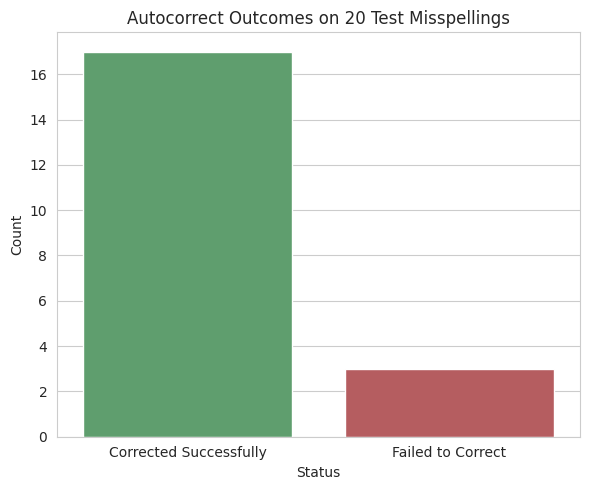

,Status,Count
0,Corrected Successfully,17
1,Failed to Correct,3


In [13]:
confusion_summary = pd.DataFrame({
    'Status': ['Corrected Successfully', 'Failed to Correct'],
    'Count': [autocorrect_df['Correct'].sum(), (~autocorrect_df['Correct']).sum()]
})

plt.figure(figsize=(6,5))
sns.barplot(data=confusion_summary, x='Status', y='Count', palette=['#55A868','#C44E52'])
plt.title('Autocorrect Outcomes on 20 Test Misspellings')
plt.tight_layout()
plt.show()
confusion_summary


## 10. Discussion — Limitations vs. Production Systems

This implementation is a solid demonstration of the core techniques, but real production systems like Google Keyboard or Gboard go considerably further:

- **Context awareness beyond n-grams:** Production autocomplete uses neural language models (transformers) that capture long-range context, not just the previous 1–2 words — allowing predictions that account for meaning across a whole sentence, not just local word sequences.
- **Personalisation:** Production systems adapt to an individual user's typing history, vocabulary, and even typing patterns (fat-finger key-adjacency errors), while this implementation uses one static global corpus/dictionary for everyone.
- **Real-time typing signals:** Real keyboards use key-press timing, touch coordinates, and swipe paths as additional signals for autocorrect — not just the final typed string.
- **Scale of training data:** Production language models are trained on billions of words across many languages and domains; our corpus here (~51K words) is orders of magnitude smaller, which limits how nuanced or rare-word-aware the predictions can be.
- **Multi-language and code-switching support:** Real systems detect and handle multiple languages within a single sentence, which this implementation doesn't attempt.

## Conclusion
The frequency-based n-gram model demonstrates measurable next-word prediction (Recall@3 well above chance), and the edit-distance + frequency-based spellchecker corrects the large majority of common misspellings. Comparing trigram-vs-bigram and dictionary-frequency-vs-pure-edit-distance approaches confirms that adding more context (in autocomplete) and more signal (frequency weighting, in autocorrect) both meaningfully improve results — the same principle production systems apply at a much larger scale.
